# Feature engineering

Notebook objectives:

- load the cleaned dataset;
- create calendar-based features;
- create weather-based features;
- prepare a modeling dataset for the baseline model step.

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [30]:
data_path = "../data/processed/electricity_weather_cleaned.csv"
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])

df.head()

,date,AWND,PRCP,TMAX,TMIN,daily_consumption,is_low_consumption_outlier
0,2006-12-16,2.5,0.0,10.6,5.0,1209.176,False
1,2006-12-17,2.6,0.0,13.3,5.6,3390.460,False
2,2006-12-18,2.4,0.0,15.0,6.7,2203.826,False
3,2006-12-19,2.4,0.0,7.2,2.2,1666.194,False
4,2006-12-20,2.4,0.0,7.2,1.1,2225.748,False


In [31]:
df_features = df.copy()

In [32]:
df_features["year"] = df_features["date"].dt.year
df_features["month"] = df_features["date"].dt.month
df_features["day_of_week"] = df_features["date"].dt.dayofweek
df_features["day_of_year"] = df_features["date"].dt.dayofyear
df_features["is_weekend"] = df_features["day_of_week"].isin([5, 6])

df_features.head()

,date,AWND,PRCP,TMAX,TMIN,daily_consumption,is_low_consumption_outlier,year,month,day_of_week,day_of_year,is_weekend
0,2006-12-16,2.5,0.0,10.6,5.0,1209.176,False,2006,12,5,350,True
1,2006-12-17,2.6,0.0,13.3,5.6,3390.460,False,2006,12,6,351,True
2,2006-12-18,2.4,0.0,15.0,6.7,2203.826,False,2006,12,0,352,False
3,2006-12-19,2.4,0.0,7.2,2.2,1666.194,False,2006,12,1,353,False
4,2006-12-20,2.4,0.0,7.2,1.1,2225.748,False,2006,12,2,354,False


## Weather-based features

Raw weather variables are useful, but derived weather features can make some relationships easier for a model to learn.

In [33]:
df_features["temperature_range"] = df_features["TMAX"] - df_features["TMIN"]
df_features["temperature_mean"] = (df_features["TMAX"] + df_features["TMIN"]) / 2

df_features.head()

,date,AWND,PRCP,TMAX,TMIN,daily_consumption,is_low_consumption_outlier,year,month,day_of_week,day_of_year,is_weekend,temperature_range,temperature_mean
0,2006-12-16,2.5,0.0,10.6,5.0,1209.176,False,2006,12,5,350,True,5.6,7.80
1,2006-12-17,2.6,0.0,13.3,5.6,3390.460,False,2006,12,6,351,True,7.7,9.45
2,2006-12-18,2.4,0.0,15.0,6.7,2203.826,False,2006,12,0,352,False,8.3,10.85
3,2006-12-19,2.4,0.0,7.2,2.2,1666.194,False,2006,12,1,353,False,5.0,4.70
4,2006-12-20,2.4,0.0,7.2,1.1,2225.748,False,2006,12,2,354,False,6.1,4.15


## Energy demand temperature features

Heating and cooling degree days estimate how far the daily average temperature is from a comfortable reference temperature.

In [34]:
base_temperature = 18

df_features["heating_degree_days"] = np.maximum(base_temperature - df_features["temperature_mean"], 0)

df_features["cooling_degree_days"] = np.maximum( df_features["temperature_mean"] - base_temperature, 0)

df_features[
    [
        "temperature_mean",
        "heating_degree_days",
        "cooling_degree_days"

    ]
].head()

,temperature_mean,heating_degree_days,cooling_degree_days
0,7.80,10.20,0.0
1,9.45,8.55,0.0
2,10.85,7.15,0.0
3,4.70,13.30,0.0
4,4.15,13.85,0.0


In [35]:
df_features[
    [
        "temperature_mean",
        "heating_degree_days",
        "cooling_degree_days"

    ]
].describe()

,temperature_mean,heating_degree_days,cooling_degree_days
count,1433.000000,1433.000000,1433.00000
mean,13.164375,6.746825,1.91120
std,9.478471,7.376104,3.10281
min,-10.850000,0.000000,0.00000
25%,5.550000,0.000000,0.00000
50%,13.600000,4.400000,0.00000
75%,21.400000,12.450000,3.40000
max,33.300000,28.850000,15.30000


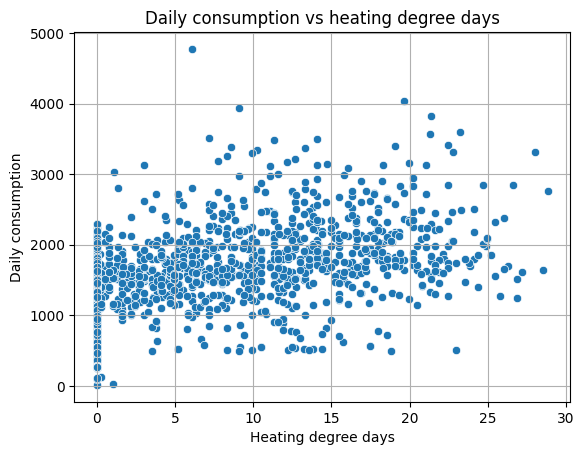

In [36]:
plt.Figure(figsize=(7,4))

sns.scatterplot(
    data= df_features,
    x="heating_degree_days",
    y="daily_consumption"
)

plt.title("Daily consumption vs heating degree days")
plt.xlabel("Heating degree days")
plt.ylabel("Daily consumption")
plt.grid(True)

plt.show()

The scatterplot suggests a positive relationship between heating degree days and daily electricity consumption. Colder days tend to be associated with higher consumption, which is consistent with heating-related demand.

However, the relationship is not perfectly linear and the points remain widely dispersed. This means that heating degree days may be useful for modeling, but additional weather and calendar features are still needed.

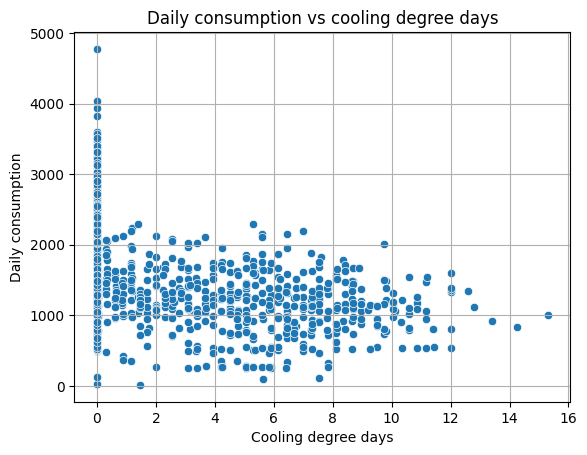

In [37]:
plt.Figure(figsize=(7,4))

sns.scatterplot(
    data= df_features,
    x= "cooling_degree_days",
    y= "daily_consumption"
)

plt.title("Daily consumption vs cooling degree days")
plt.xlabel("Cooling degree days")
plt.ylabel("Daily consumption")
plt.grid(True)
plt.show()

The cooling degree days plot shows a weaker relationship with daily electricity consumption. High consumption peaks mostly occur when cooling degree days are equal to zero, which suggests that the strongest demand peaks are more likely related to cold weather than warm weather.

For this dataset, heating-related features appear more informative than cooling-related features.

In [38]:
feature_columns = [
    "AWND",
    "PRCP",
    "TMAX",
    "TMIN",
    "temperature_range",
    "temperature_mean",
    "heating_degree_days",
    "cooling_degree_days",
    "month",
    "day_of_week",
    "day_of_year",
    "is_weekend",
    "daily_consumption"
]

df_features[feature_columns].corr()["daily_consumption"].sort_values()

temperature_mean      -0.531890
TMIN                  -0.526822
TMAX                  -0.525494
cooling_degree_days   -0.443751
temperature_range     -0.188492
month                 -0.079215
day_of_year           -0.077380
PRCP                  -0.036427
day_of_week            0.156429
is_weekend             0.197607
AWND                   0.236338
heating_degree_days    0.496824
daily_consumption      1.000000
Name: daily_consumption, dtype: float64

## Feature correlation takeaways

The strongest relationships with `daily_consumption` are related to temperature. `temperature_mean`, `TMAX`, and `TMIN` are negatively correlated with consumption, while `heating_degree_days` is positively correlated.

This confirms that colder days are associated with higher electricity consumption in this dataset. Calendar variables such as `is_weekend` show a weaker but still visible relationship.

These engineered features will be useful candidates for the baseline modeling step.

In [39]:
output_path = "../data/processed/electricity_weather_features.csv"

df_features.to_csv(output_path, index=False)

In [40]:
pd.read_csv(output_path).head()

,date,AWND,PRCP,TMAX,TMIN,daily_consumption,is_low_consumption_outlier,year,month,day_of_week,day_of_year,is_weekend,temperature_range,temperature_mean,heating_degree_days,cooling_degree_days
0,2006-12-16,2.5,0.0,10.6,5.0,1209.176,False,2006,12,5,350,True,5.6,7.80,10.20,0.0
1,2006-12-17,2.6,0.0,13.3,5.6,3390.460,False,2006,12,6,351,True,7.7,9.45,8.55,0.0
2,2006-12-18,2.4,0.0,15.0,6.7,2203.826,False,2006,12,0,352,False,8.3,10.85,7.15,0.0
3,2006-12-19,2.4,0.0,7.2,2.2,1666.194,False,2006,12,1,353,False,5.0,4.70,13.30,0.0
4,2006-12-20,2.4,0.0,7.2,1.1,2225.748,False,2006,12,2,354,False,6.1,4.15,13.85,0.0


## Feature dataset export

The feature-engineered dataset is exported to `data/processed/electricity_weather_features.csv`.

This dataset includes:

- cleaned weather and consumption data;
- calendar-based features;
- weather-derived features;
- heating and cooling degree day features;
- the low consumption outlier flag created during the cleaning step.

This file will be used in the next step to build a baseline prediction model.